In [2]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import anndata as ad

In [3]:
sc.settings.verbosity = 3         
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

In [4]:
%cd /home/orimosko/projects/phago/spatial

/home/orimosko/projects/phago/spatial


In [5]:
adata = sc.read_csv("/mc_disk2/data/downloaded_phago/melanoma_spatial/scRNA/NRAS13all.csv")

In [6]:
adata = adata.T

In [8]:
adata

AnnData object with n_obs × n_vars = 43028 × 18468

In [9]:
adata.obs['Sample'] = adata.obs_names.str.split("_").str[1]

In [12]:
adata = adata[~adata.obs.Sample.isna()]

In [13]:
annot_dict = pd.read_csv("/mc_disk2/data/downloaded_phago/melanoma_spatial/scRNA/Nras_allograft_ALL cells_cluster_annotation.txt", index_col=0, sep="\t").to_dict()['cell_type']

In [14]:
adata.obs['original_annot'] = [annot_dict.get(x) for x in adata.obs_names]

/tmp/ipykernel_2275243/1997488472.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['original_annot'] = [annot_dict.get(x) for x in adata.obs_names]


In [15]:
adata.obs.original_annot.value_counts()

original_annot
Malignant              20179
Monocyte/macrophage     6574
CAF                     6476
T/NK cell               4103
DC                       674
EC                       487
B-cell                   464
Pericyte                 150
Name: count, dtype: int64

In [16]:
adata.layers['counts'] = adata.X.copy()

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [18]:
sc.pp.log1p(adata)

In [19]:
sc.pp.highly_variable_genes(adata)

extracting highly variable genes
    finished (0:00:13)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


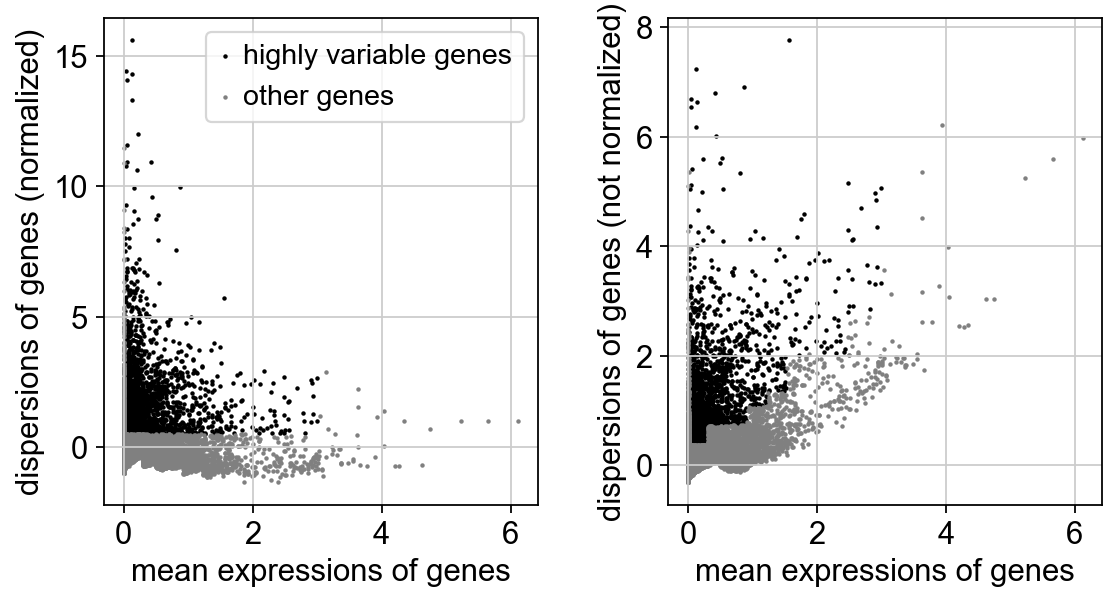

In [20]:
sc.pl.highly_variable_genes(adata)

In [21]:
adata.var.highly_variable.sum()

np.int64(2356)

In [22]:
sc.pp.pca(adata, use_highly_variable=True)

computing PCA
    with n_comps=50


/opt/bin/envs/spatial_py/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:07)


In [23]:
sc.pp.neighbors(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:25)


In [24]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:21)


In [30]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering
    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)


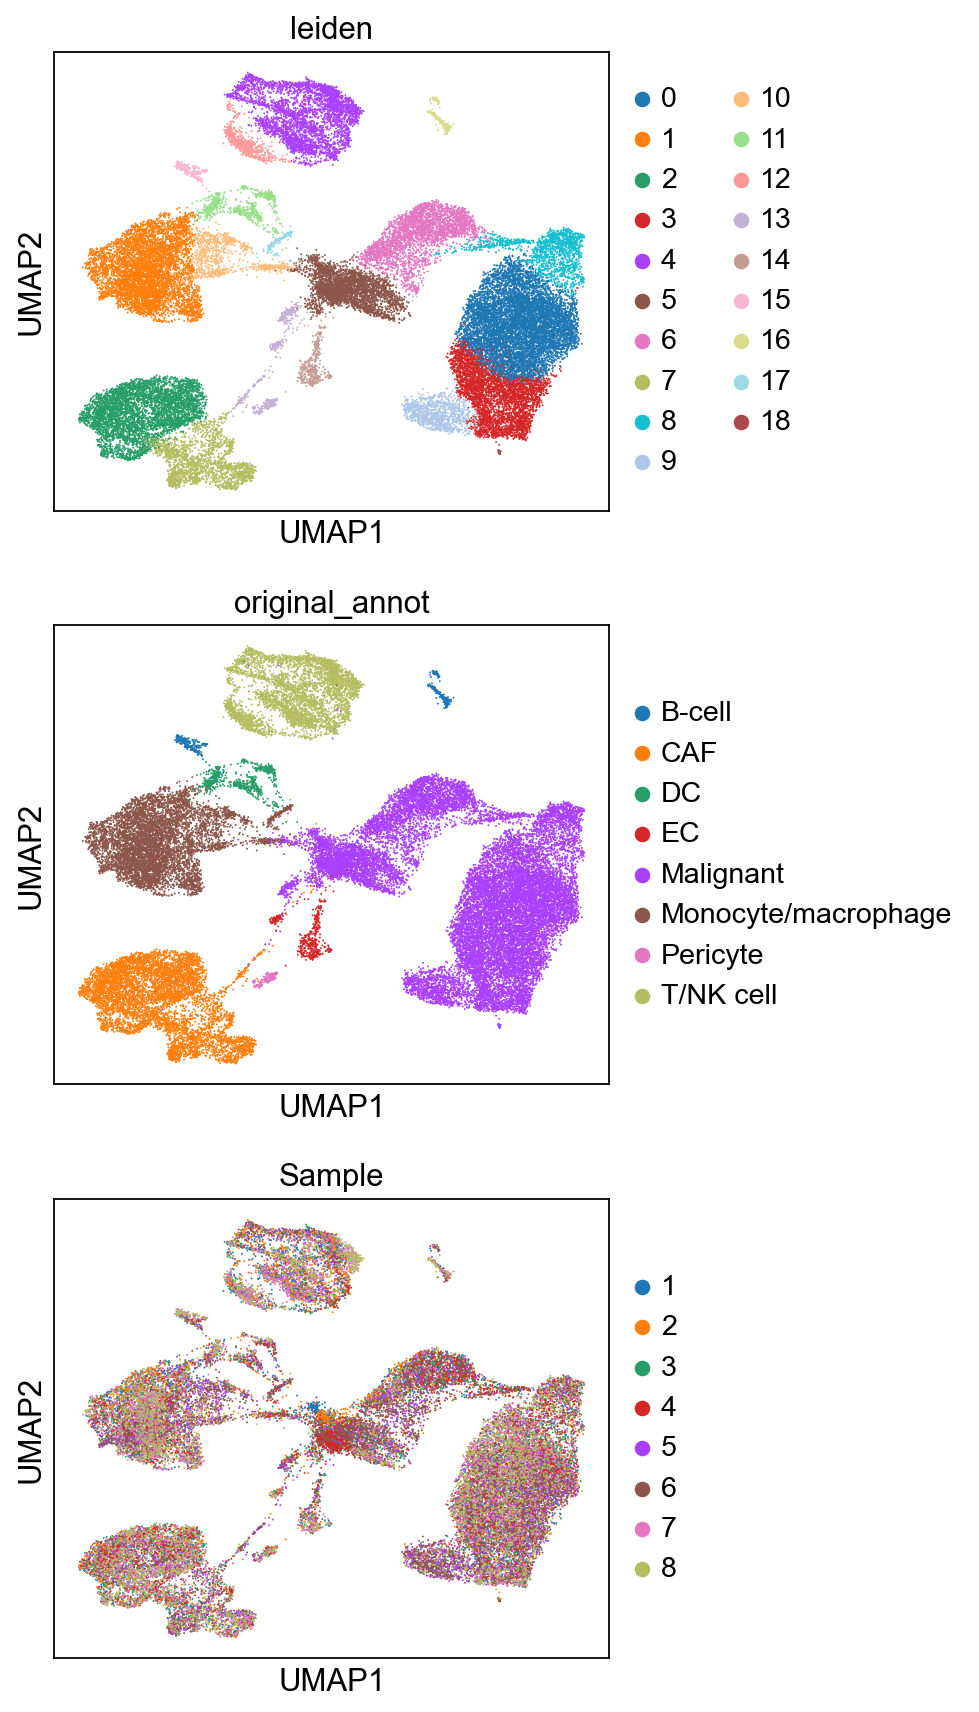

In [35]:
sc.pl.umap(adata, color=['leiden', 'original_annot', 'Sample'], ncols=1)

In [36]:
adata.write_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_scrna.h5ad")

In [206]:
adata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_scrna.h5ad")

In [207]:
macdata = adata[adata.obs['original_annot'].isin(['Monocyte/macrophage'])].copy()

In [208]:
sc.pp.highly_variable_genes(macdata)

extracting highly variable genes


    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


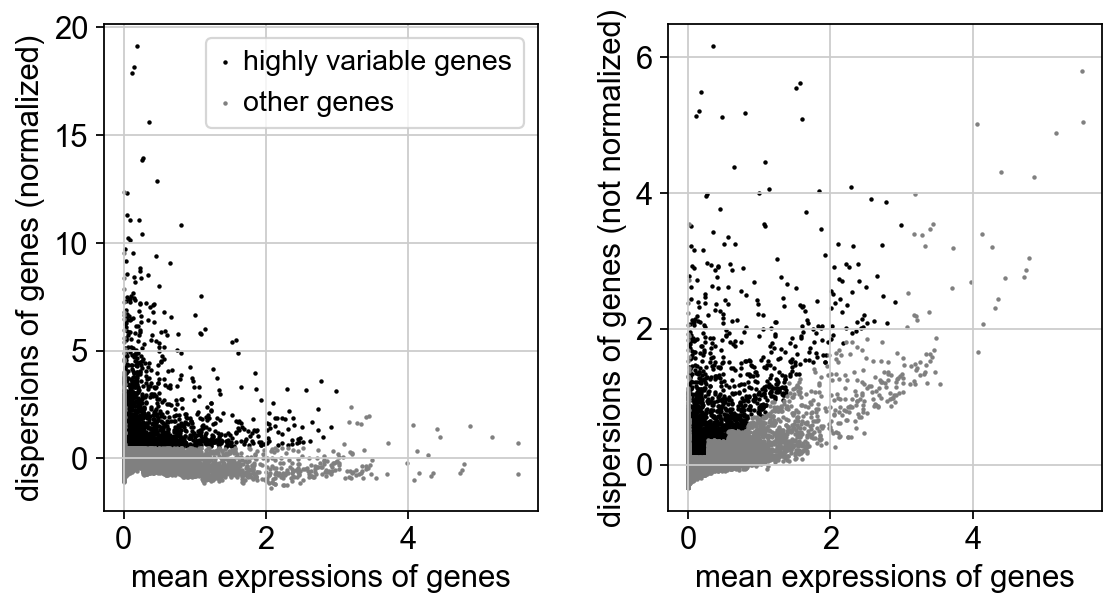

In [209]:
sc.pl.highly_variable_genes(macdata)

In [210]:
macdata.var.highly_variable.sum()

np.int64(2101)

In [211]:
sc.pp.pca(macdata, use_highly_variable=True)

computing PCA
    with n_comps=50


/opt/bin/envs/spatial_py/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)


In [212]:
sc.pp.neighbors(macdata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [213]:
sc.tl.umap(macdata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)


In [214]:
sc.tl.leiden(macdata, resolution=0.5)

running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


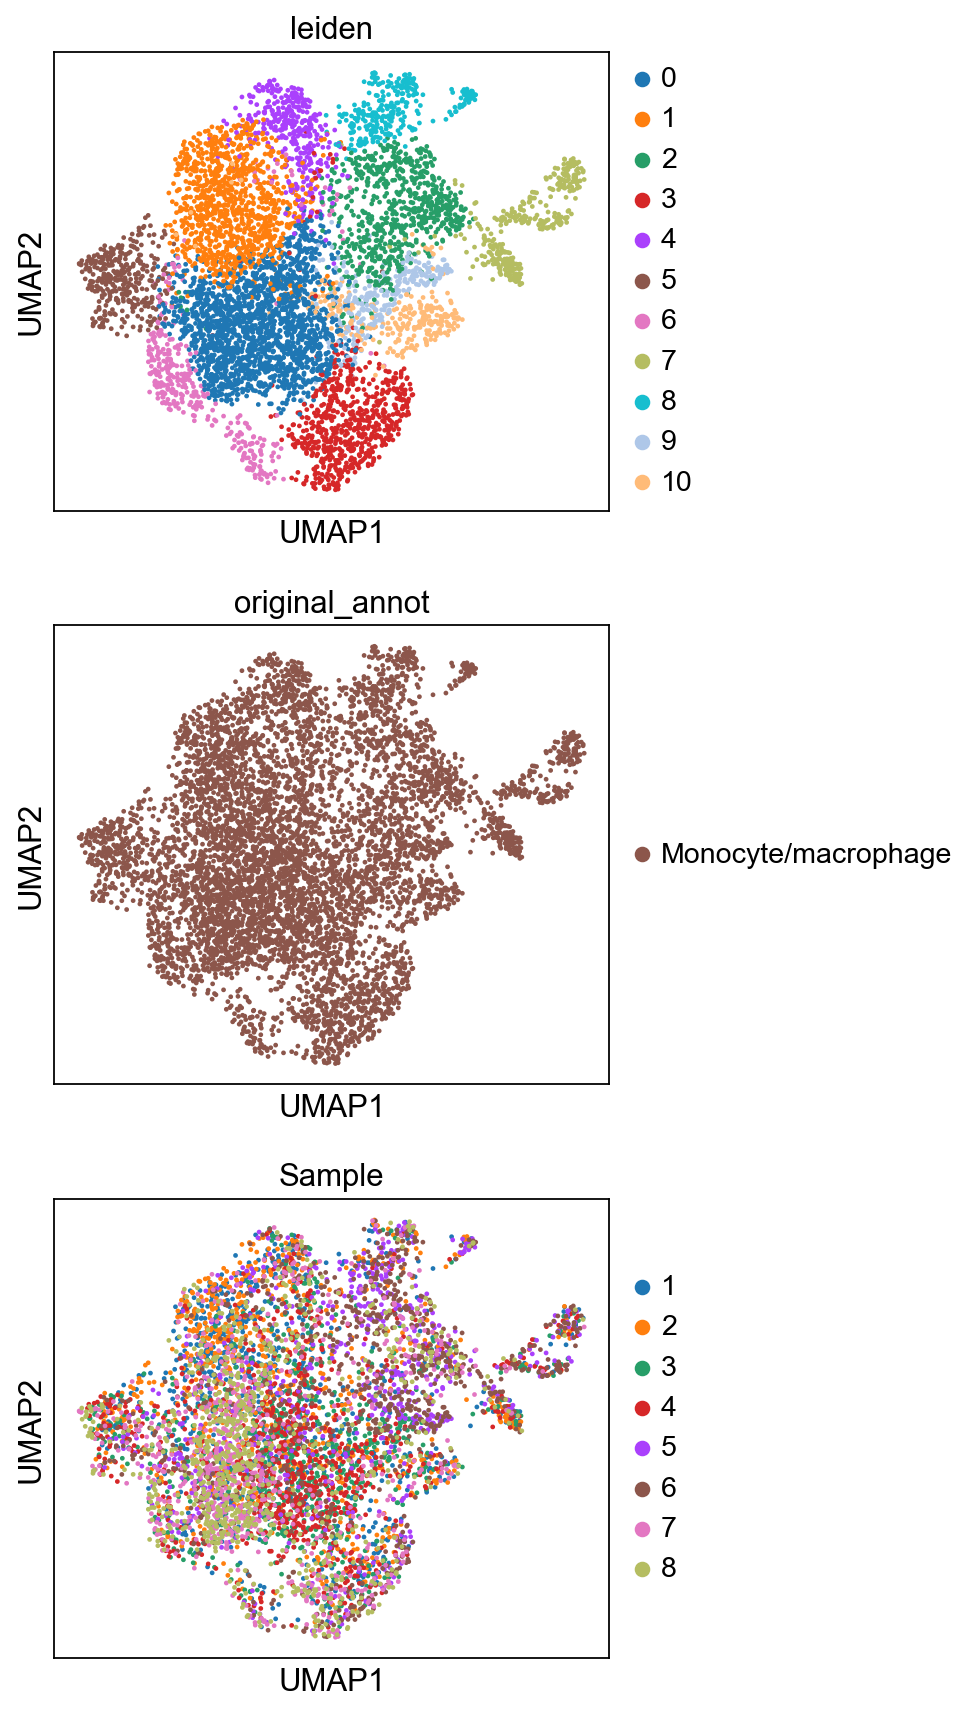

In [215]:
sc.pl.umap(macdata, color=['leiden', 'original_annot', 'Sample'], ncols=1)

In [218]:
sc.tl.rank_genes_groups(macdata, 'leiden')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:04)


In [219]:
sc.tl.dendrogram(macdata, 'leiden')

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


In [220]:
gene_dict = {str(i): [l[i] for l in macdata.uns["rank_genes_groups"]["names"][:50]] 
             for i in macdata.obs.leiden.values.categories}
prev_vals = []
for k in gene_dict.keys():
    gene_dict[k] = [i for i in gene_dict[k] if i not in prev_vals]
    prev_vals += gene_dict[k]    

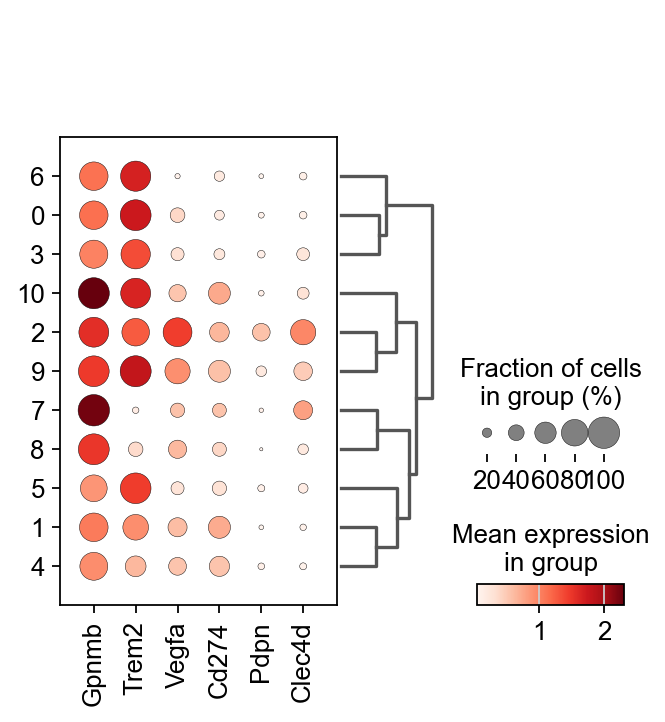

In [221]:
sc.pl.dotplot(macdata, ['Gpnmb', 'Trem2', 'Vegfa', 'Cd274', 'Pdpn', 'Clec4d'], groupby='leiden', dendrogram=True)

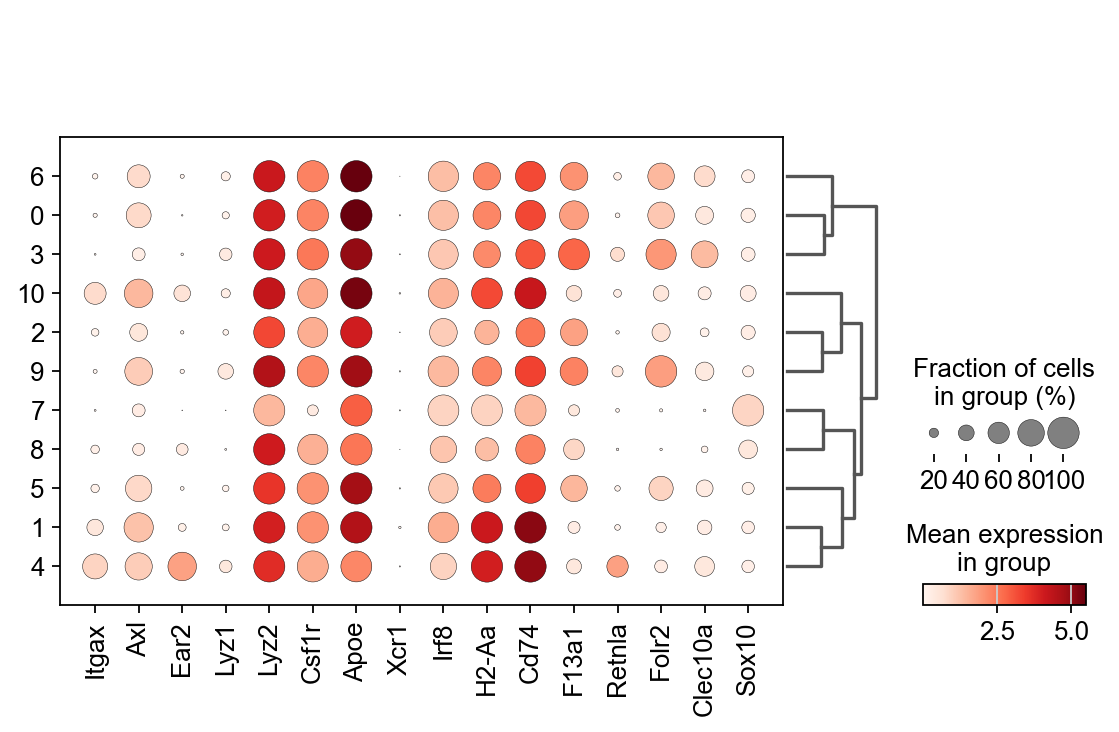

In [222]:
sc.pl.dotplot(macdata, ['Itgax', 'Axl', 'Ear2', 'Lyz1', 'Lyz2', 'Csf1r', 'Apoe', 'Xcr1', 'Irf8', 'H2-Aa', 'Cd74', 'F13a1', 'Retnla', 'Folr2', 'Clec10a', 'Sox10'], groupby='leiden', dendrogram=True)

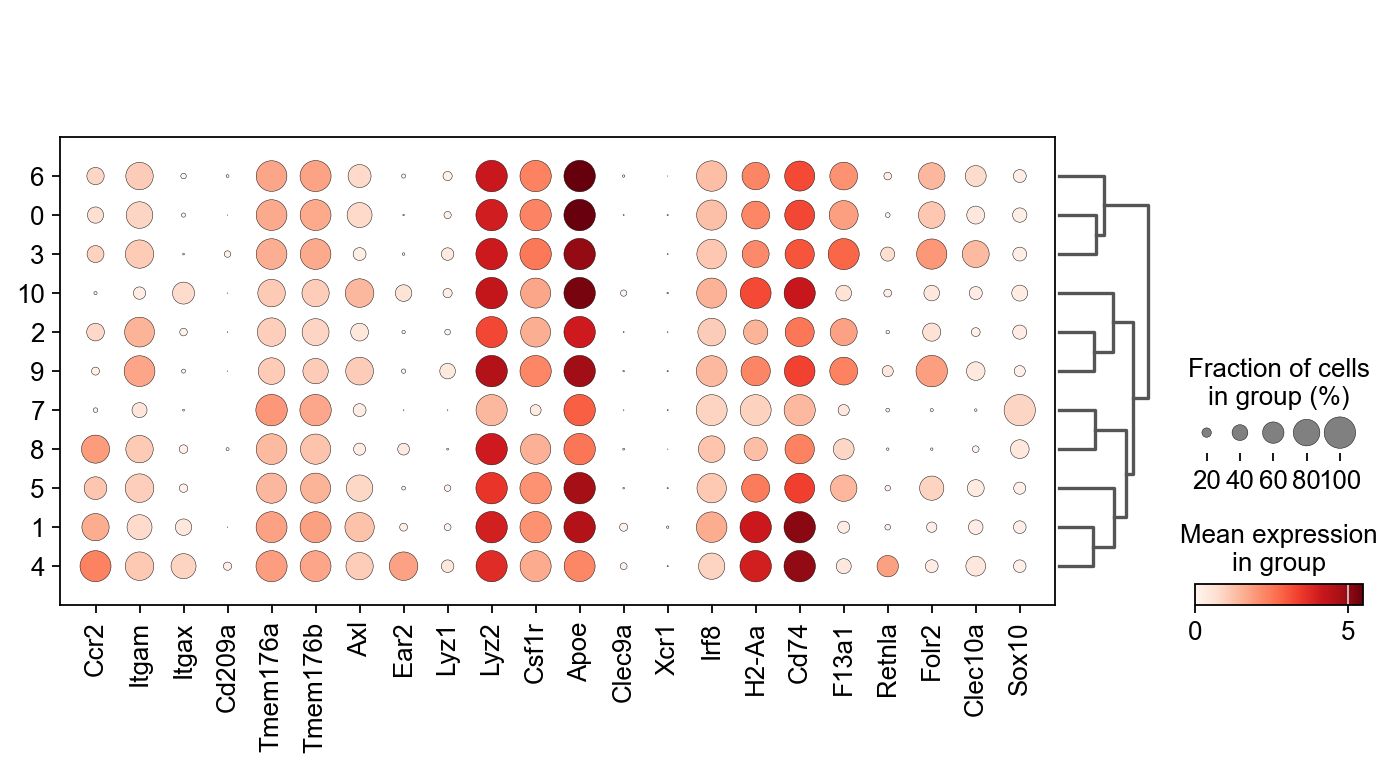

In [223]:
sc.pl.dotplot(macdata, ['Ccr2', 'Itgam', 'Itgax', 'Cd209a', 'Tmem176a', 'Tmem176b', 'Axl', 'Ear2', 'Lyz1', 'Lyz2', 'Csf1r', 'Apoe', 'Clec9a', 'Xcr1', 'Irf8', 'H2-Aa', 'Cd74', 'F13a1', 'Retnla', 'Folr2', 'Clec10a', 'Sox10'], groupby='leiden', dendrogram=True)

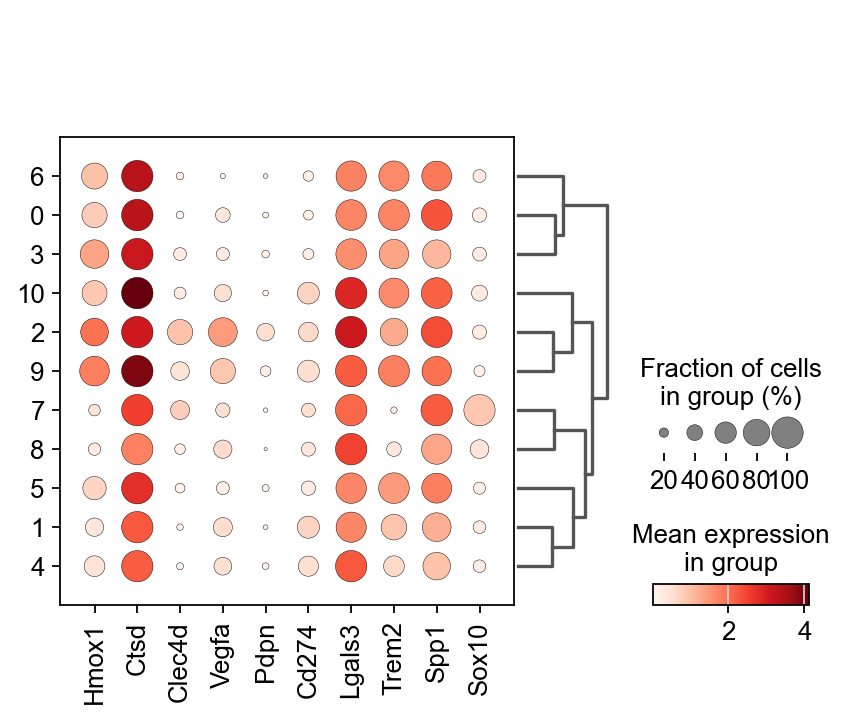

In [224]:
sc.pl.dotplot(macdata, ['Hmox1', 'Ctsd', 'Clec4d', 'Vegfa', 'Pdpn', 'Cd274', 'Lgals3', 'Trem2', 'Spp1', 'Sox10'], groupby='leiden', dendrogram=True)

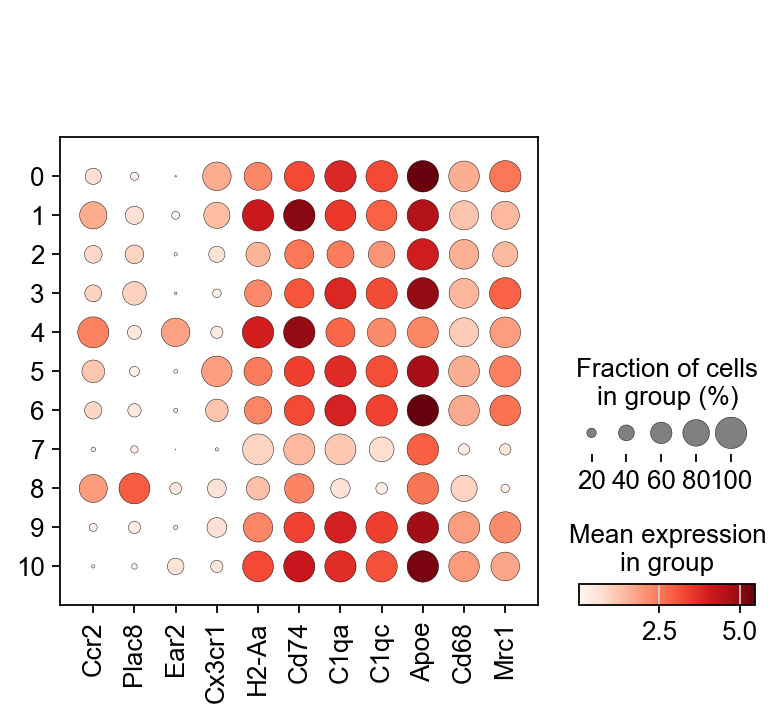

In [228]:
sc.pl.dotplot(macdata, ['Ccr2', 'Plac8', 'Ear2', 'Cx3cr1', 'H2-Aa', 'Cd74', 'C1qa', 'C1qc', 'Apoe', 'Cd68', 'Mrc1'], groupby='leiden')

In [ ]:
macdata.obs['annots'] = ['Doublets cells' if x == '7' else 'MonMacs' for x in macdata.obs['leiden']]

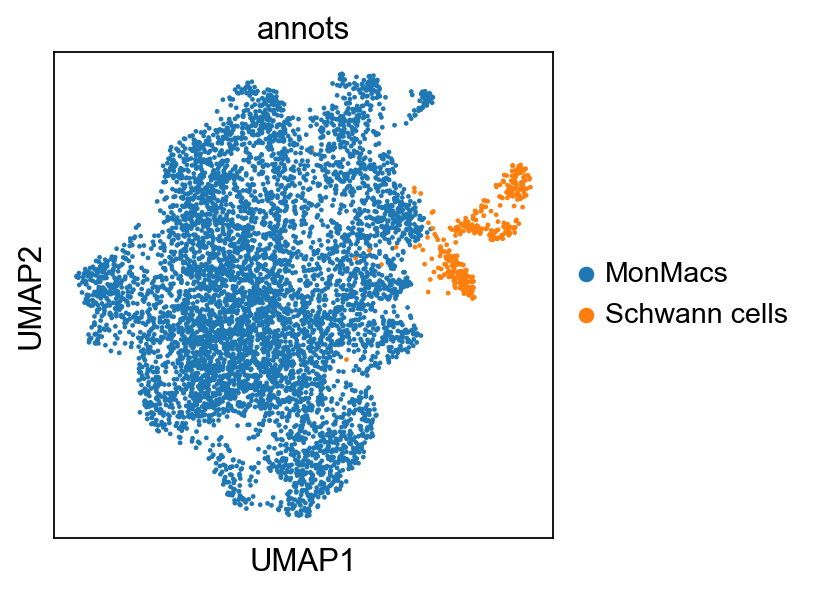

In [235]:
sc.pl.umap(macdata, color=['annots'], ncols=1)

In [236]:
macdata.write_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_macrophages_scrna.h5ad")

In [119]:
tdata = adata[adata.obs['original_annot'].isin(['T/NK cell'])].copy()

In [121]:
sc.pp.highly_variable_genes(tdata)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


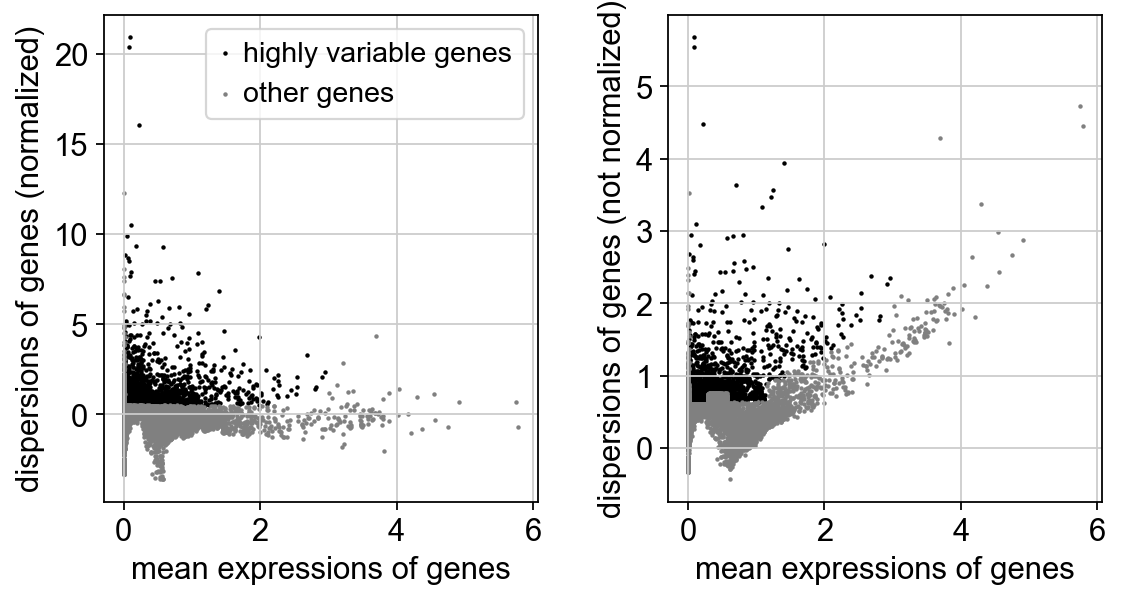

In [122]:
sc.pl.highly_variable_genes(tdata)

In [123]:
tdata.var.highly_variable.sum()

np.int64(3151)

In [124]:
sc.pp.pca(tdata, use_highly_variable=True)

computing PCA
    with n_comps=50


/opt/bin/envs/spatial_py/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:00)


In [125]:
sc.pp.neighbors(tdata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [126]:
sc.tl.umap(tdata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


In [129]:
sc.tl.leiden(tdata, resolution=0.5)

running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


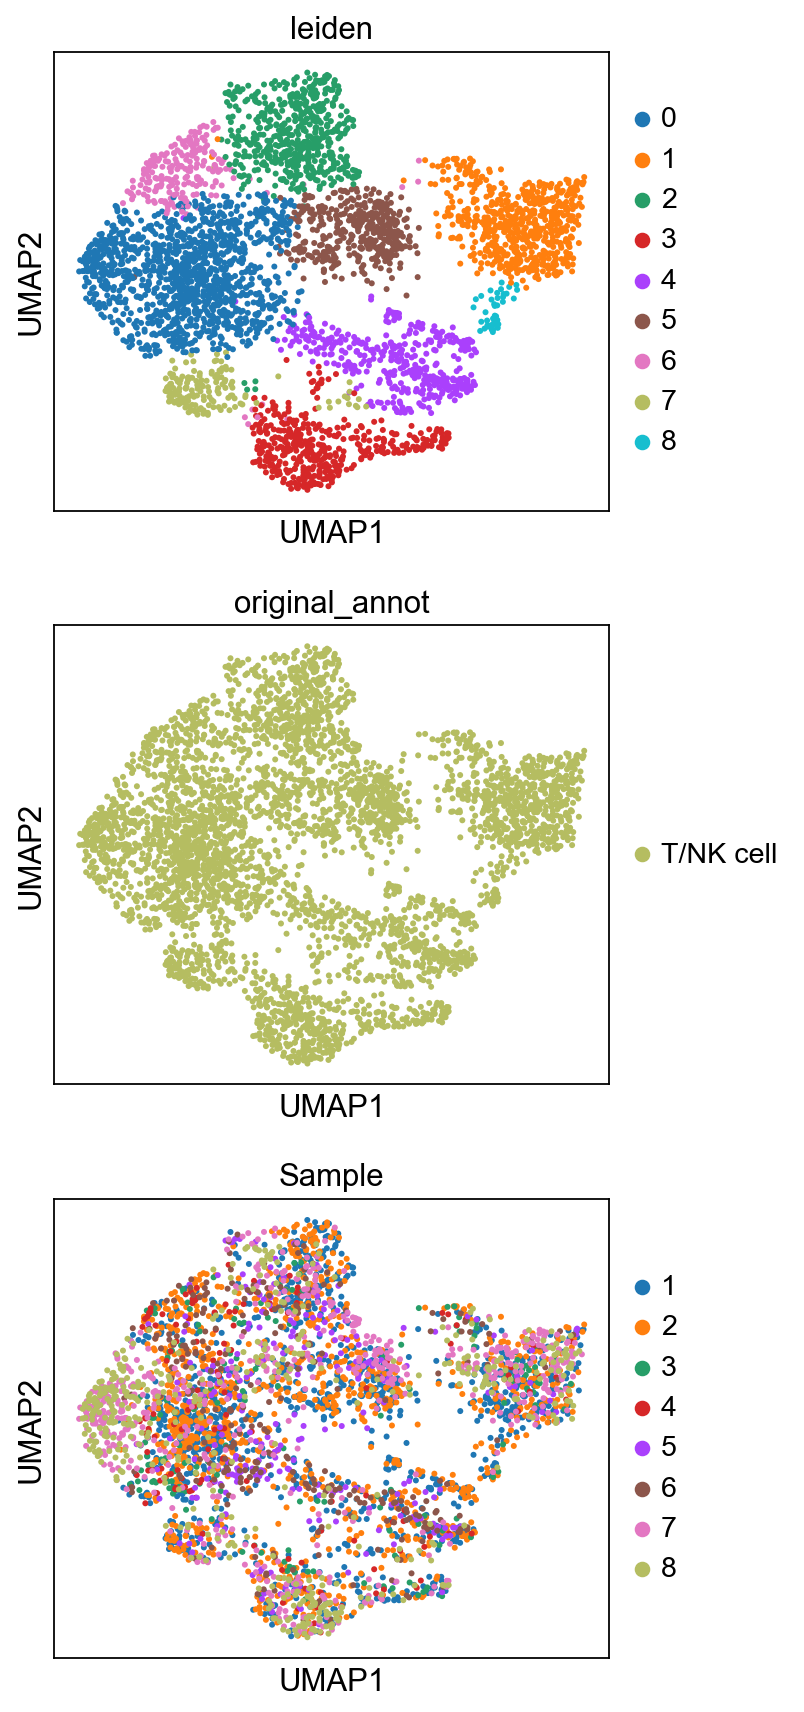

In [147]:
sc.pl.umap(tdata, color=['leiden', 'original_annot', 'Sample'], ncols=1)

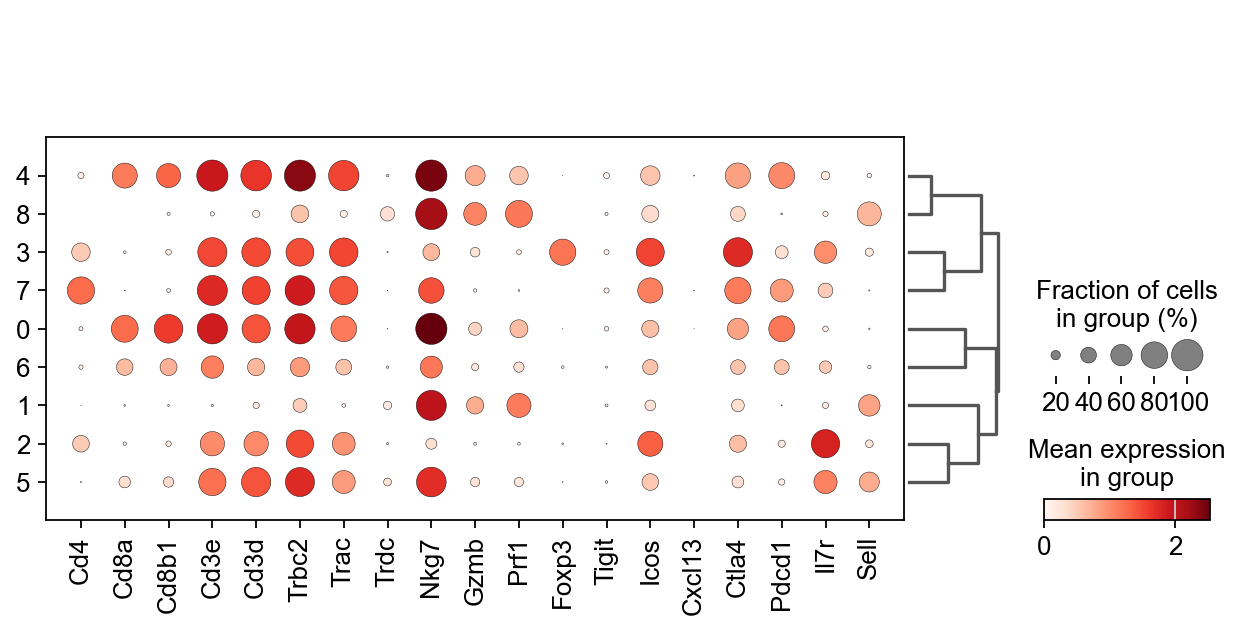

In [142]:
sc.pl.dotplot(tdata, ["Cd4", "Cd8a", "Cd8b1", "Cd3e", "Cd3d", "Trbc2", "Trac", "Trdc", "Nkg7", "Gzmb", "Prf1", "Foxp3", "Tigit", "Icos", "Cxcl13", "Ctla4", "Pdcd1", "Il7r", "Sell"], 
              groupby='leiden', dendrogram=True)

In [ ]:
t_annots = ['CD8 T cells', 'NK cells', 'CD4 T cells', 'Treg', 'CD8 T cells', 'CD8 T cells', 'CD8 T cells', 'CD4 T cells', 'NK cells']

In [164]:
t_annot_order = ['NK cells', 'CD8 T cells', 'CD4 T cells', 'Treg']

In [165]:
tdata.obs['annots'] = pd.Categorical([t_annots[int(i)] for i in tdata.obs.leiden], categories=t_annot_order, ordered=True)

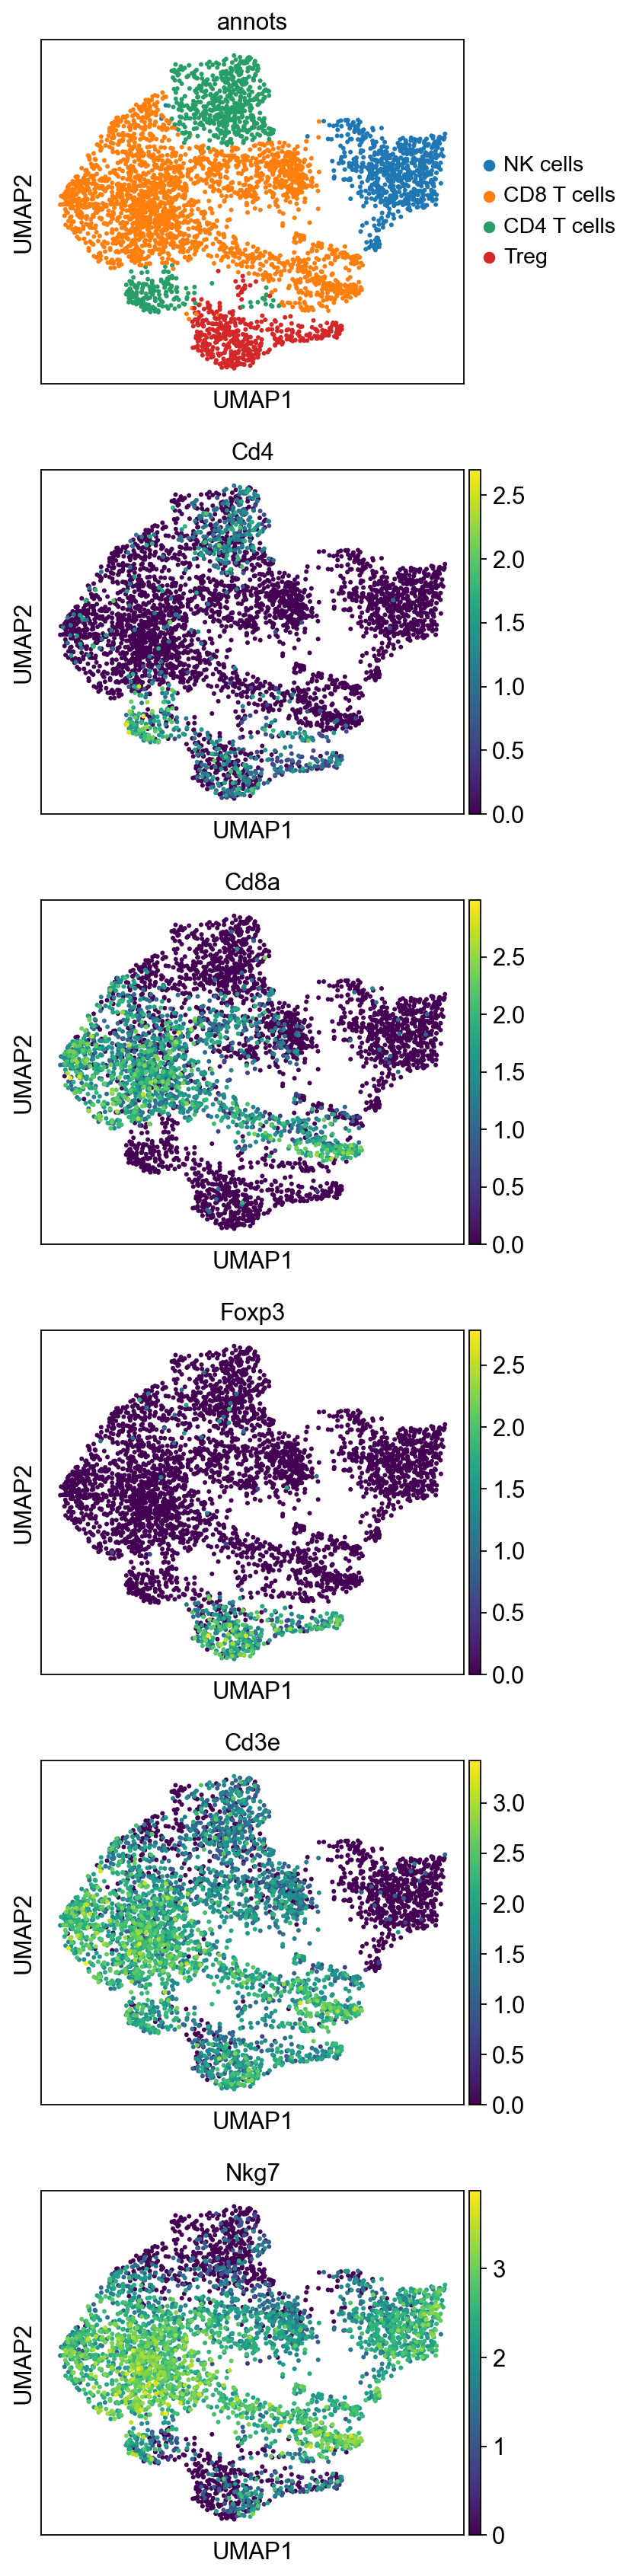

In [169]:
sc.pl.umap(tdata, color=['annots', 'Cd4', 'Cd8a', 'Foxp3', 'Cd3e', 'Nkg7'], ncols=1)

In [170]:
tdata.write_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_tcells_scrna.h5ad")

In [237]:
macdata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_macrophages_scrna.h5ad")
tdata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_tcells_scrna.h5ad")

In [238]:
# Priority: use tdata.obs['annots'] if present, then macdata.obs['annots'], then fallback to adata.obs['original_annot']
original = adata.obs['original_annot']
t_series = tdata.obs['annots'].reindex(adata.obs_names)
mac_series = macdata.obs['annots'].reindex(adata.obs_names)

new_annots = t_series.combine_first(mac_series).combine_first(original)

# assign to adata
adata.obs['annots'] = new_annots

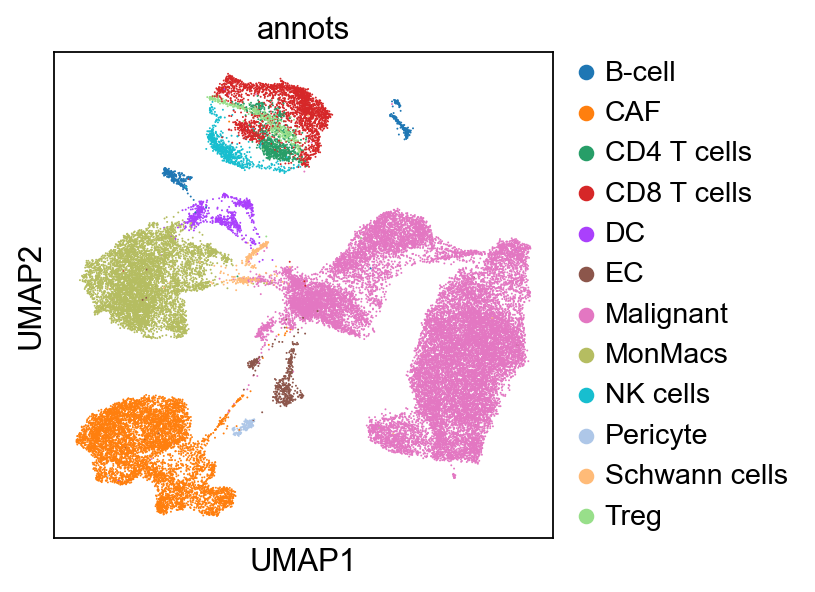

In [239]:
sc.pl.umap(adata, color='annots')

In [240]:
adata.write_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_scrna_annotated.h5ad")

In [26]:
sns.set_context("paper", font_scale=1.0, rc={'font.size': 7, 'pdf.fonttype': 42})

In [27]:
plt.rcParams['pdf.fonttype'] = 42

In [28]:
plt.rcParams.update({'font.size': 7})

In [6]:
adata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/spatial_melanoma_scrna_annotated.h5ad")

In [ ]:
annot_order = ['Malignant',
               'Doublets cells',
               'EC',
               'Pericyte',
               'CAF',
               'NK cells',
               'CD8 T cells',
               'CD4 T cells',
               'Treg',
               'B-cell',
               'DC',
               'MonMacs']

In [41]:
adata.obs['annots'] = pd.Categorical(adata.obs['annots'], categories=annot_order, ordered=True)

In [42]:
adata.uns['annots_colors']

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a'],
      dtype=object)

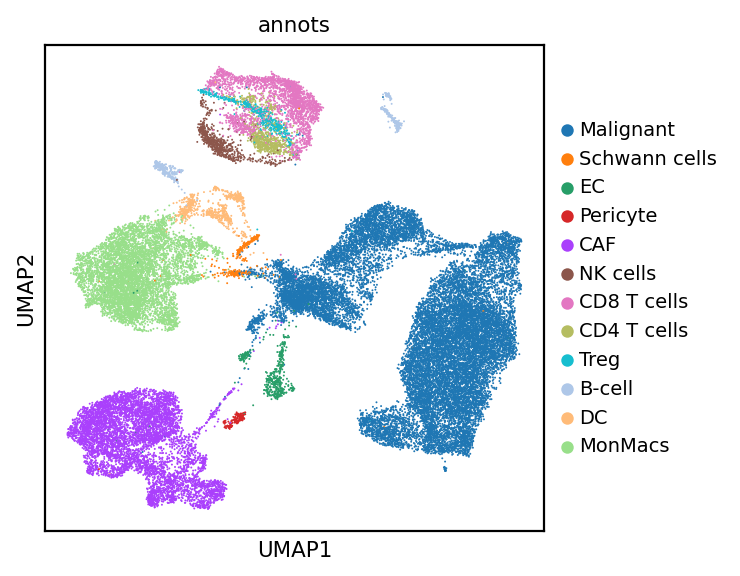

In [43]:
sc.pl.umap(adata, color='annots', save='_spatial_scrna.pdf')

In [ ]:
marker_genes = ['Gjc3', 'Cdh19', 'Sox10', 'Plp1', 'Dct',
                'Pecam1', 'Cdh5', 'Col4a1', 
                'Rgs5', 'Pdgfrb', 
                'Col1a1', 'Col3a1', 
                'Serpinf1', 'Pdgfra', 
                'Gzma', 'Ncr1', 'Klrb1c', 'Nkg7', 
                'Cd8a', 'Cd8b1', 'Cd3e', 'Cd3d', 'Trbc2',
                'Cd4',
                'Ctla4', 'Icos','Foxp3', 
                'Cd79a', 'Cd79b', 'Ms4a1',
                'Cd74', 'H2-Aa', 'Itgax', 'Flt3',
                'Csf1r', 'C1qa', 'Cd68']

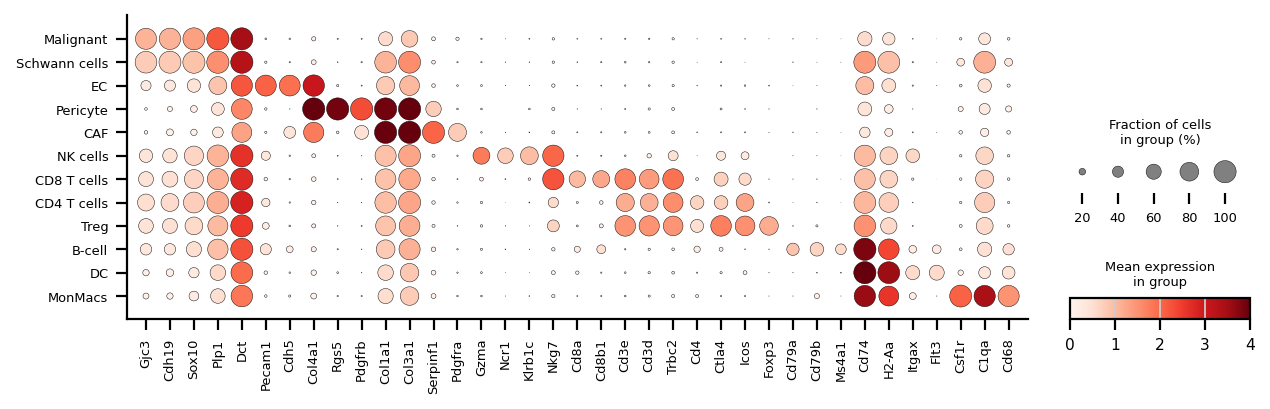

In [70]:
dot = sc.pl.dotplot(
    adata,
    marker_genes, 
    groupby='annots',
    figsize=(9, 2.5),
    vmax=4,
    return_fig=True
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

fig.savefig('figures/dotplot.pdf')